# CS106 - Sesión 8 | Notebook 36: El Veredicto de la Normalidad (Shapiro-Wilk) 🔔

Antes de comparar grupos, debemos responder una pregunta fundamental: **¿Mis datos siguen una distribución Normal (Campana de Gauss)?**

De esta respuesta depende el camino que tomaremos:
1.  **Camino Paramétrico (Normal):** Usaremos pruebas potentes como la t-Student.
2.  **Camino No Paramétrico (No Normal):** Usaremos pruebas robustas como Wilcoxon.

Hoy aprenderemos a usar la inspección visual (Gráficos Q-Q) y la prueba matemática de **Shapiro-Wilk** para tomar esta decisión con rigor científico.

## 1. ¿Qué tan cerca estamos de la línea?
Un **Gráfico Q-Q (Quantile-Quantile)** compara los cuantiles de nuestros datos contra los cuantiles de una distribución normal teórica.
* Si los puntos caen sobre la línea diagonal, los datos son **Normales**.
* Si los puntos se alejan mucho (formando curvas o "S"), los datos **No son Normales**.

**Instrucción:** Vamos a evaluar visualmente la variable `edad`.

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Rows: 200 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): nombre, sexo, diagnostico
dbl (5): id_paciente, edad, glucosa_mgdl, peso_kg, estatura_m
lgl (1): hospitalizado

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


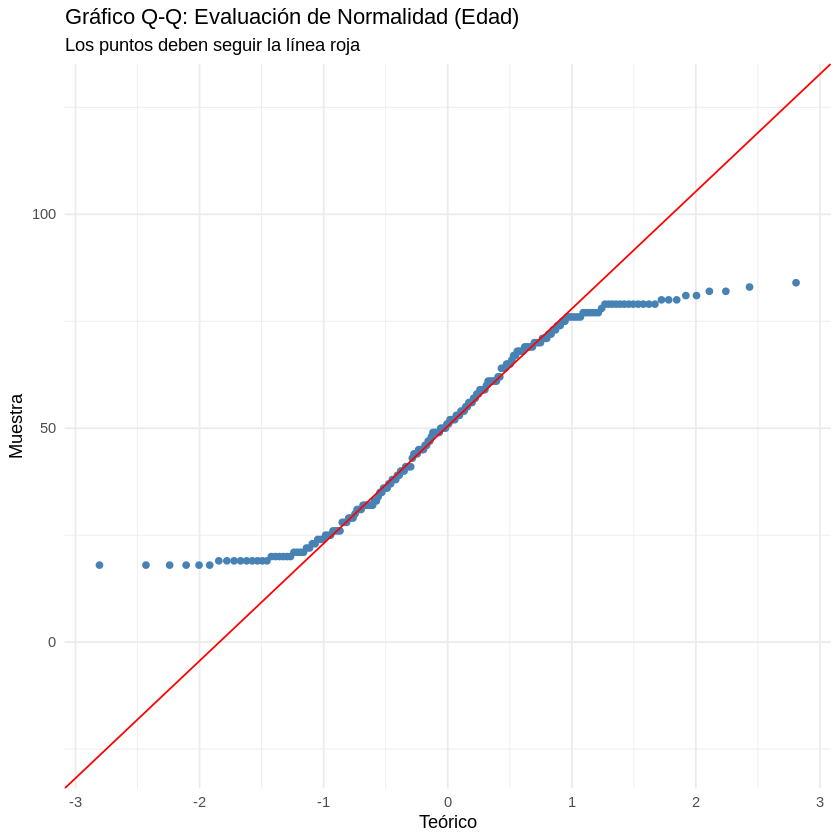

In [ ]:
library(tidyverse)
datos <- read_csv("cohorte_analisis.csv")

# Generamos el gráfico Q-Q para la Edad
ggplot(datos, aes(sample = edad)) +
  stat_qq(color = "steelblue") +
  stat_qq_line(color = "red") +
  labs(title = "Gráfico Q-Q: Evaluación de Normalidad (Edad)",
       subtitle = "Los puntos deben seguir la línea roja",
       x = "Teórico",
       y = "Muestra") +
  theme_minimal()

## 2. El rigor matemático: shapiro.test()
La inspección visual puede ser subjetiva. Para tener un veredicto oficial, usamos la prueba de Shapiro-Wilk. Aquí la regla del **valor p** es inversa a lo que solemos buscar:

* **p > 0.05:** Los datos **SÍ** son Normales (Aceptamos la hipótesis nula).
* **p < 0.05:** Los datos **NO** son Normales (Existe evidencia de desviación).

**Instrucción:** Ejecuta la prueba para la variable `glucosa_mgdl`.

In [ ]:
# Prueba de Shapiro-Wilk para Glucosa
resultado_shapiro <- shapiro.test(datos$glucosa_mgdl)

# Mostramos el resultado
print(resultado_shapiro)

# Interpretación rápida
if(resultado_shapiro$p.value > 0.05) {
  print("Veredicto: DISTRIBUCIÓN NORMAL (Usar pruebas Paramétricas)")
} else {
  print("Veredicto: DISTRIBUCIÓN NO NORMAL (Usar pruebas No Paramétricas)")
}


	Shapiro-Wilk normality test

data:  datos$glucosa_mgdl
W = 0.98939, p-value = 0.1455

[1] "Veredicto: DISTRIBUCIÓN NORMAL (Usar pruebas Paramétricas)"


## 3. Automatización: El "Check-up" de Normalidad
En una investigación real no evaluamos una sola variable. Necesitamos saber la distribución de todo nuestro set de datos para decidir qué pruebas usaremos en la "Tabla 1" y en nuestras comparaciones.

He preparado un código que recorre las variables principales de tu cohorte (`edad`, `glucosa`, `peso` y `estatura`) y ejecuta el test de Shapiro-Wilk para cada una.

**Tu misión:** Ejecuta el código, observa la lista de resultados y completa el análisis clínico en la siguiente celda.

In [ ]:
# Creamos una lista con las variables numéricas de interés
variables_interes <- c("edad", "glucosa_mgdl", "peso_kg", "estatura_m")

# Ejecutamos un ciclo para evaluar la normalidad de cada una
for (var in variables_interes) {
  cat("\n---------------------------------------------\n")
  cat("ANALIZANDO VARIABLE:", toupper(var), "\n")

  # Ejecutamos Shapiro
  prueba <- shapiro.test(datos[[var]])

  # Imprimimos p-valor
  cat("Valor p de Shapiro-Wilk:", round(prueba$p.value, 4), "\n")

  # Veredicto automático
  if(prueba$p.value > 0.05) {
    cat("RESULTADO: Distribución NORMAL ✅\n")
    cat("RECOMENDACIÓN: Usar pruebas PARAMÉTRICAS (t-Student / ANOVA)\n")
  } else {
    cat("RESULTADO: Distribución NO NORMAL ⚠️\n")
    cat("RECOMENDACIÓN: Usar pruebas NO PARAMÉTRICAS (Wilcoxon / Kruskal-Wallis)\n")
  }
}


---------------------------------------------
ANALIZANDO VARIABLE: EDAD 
Valor p de Shapiro-Wilk: 0 
RESULTADO: Distribución NO NORMAL ⚠️
RECOMENDACIÓN: Usar pruebas NO PARAMÉTRICAS (Wilcoxon / Kruskal-Wallis)

---------------------------------------------
ANALIZANDO VARIABLE: GLUCOSA_MGDL 
Valor p de Shapiro-Wilk: 0.1455 
RESULTADO: Distribución NORMAL ✅
RECOMENDACIÓN: Usar pruebas PARAMÉTRICAS (t-Student / ANOVA)

---------------------------------------------
ANALIZANDO VARIABLE: PESO_KG 
Valor p de Shapiro-Wilk: 0.1991 
RESULTADO: Distribución NORMAL ✅
RECOMENDACIÓN: Usar pruebas PARAMÉTRICAS (t-Student / ANOVA)

---------------------------------------------
ANALIZANDO VARIABLE: ESTATURA_M 
Valor p de Shapiro-Wilk: 0.6731 
RESULTADO: Distribución NORMAL ✅
RECOMENDACIÓN: Usar pruebas PARAMÉTRICAS (t-Student / ANOVA)


## 4. Análisis Integral e Interpretación
En esta sección final, se evalúa la normalidad de la variable **`glucosa_mgdl`**.

**Tu misión:**
1. Ejecuta la celda para observar los resultados de la prueba de Shapiro-Wilk.
2. Analiza el reporte impreso y completa las variables de respuesta en la parte inferior del código.
3. Recuerda: Un **p > 0.05** indica distribución normal.

In [ ]:
# --- 1. CÓDIGO INTEGRAL DE ANÁLISIS ---
# No modificar: Realiza la prueba de Shapiro-Wilk
resultado_shapiro <- shapiro.test(datos$glucosa_mgdl)
print(resultado_shapiro)

# --- 2. SECCIÓN DE RESPUESTAS (RELLENA LOS VALORES) ---

# r1: Escribe el valor p obtenido (ejemplo: 0.0001)
r1_p_valor <- 0.0000

# r2: ¿Es la distribución normal? (Escribe TRUE o FALSE)
r2_es_normal <- NULL

# r3: ¿Qué tipo de prueba sugiere este resultado? (Escribe "Parametrica" o "No parametrica")
r3_camino <- ""

# --- 3. CONSTRUCCIÓN DEL DATA FRAME ---
df_respuesta <- data.frame(
  pregunta = c("p_valor", "es_normal", "camino_sugerido"),
  respuesta = c(as.character(r1_p_valor), as.character(r2_es_normal), r3_camino)
)
print(df_respuesta)

In [ ]:
# Ejecuta para guardar tu avance
source("utilidades.r")
guardar_36(df_respuesta)